# Practical 05: ERP data analysis for Decision Making

In [1]:
# Credits: this notebook was written by Ilaria Gavetti and Nin Khodorivsko for the Cognitive Neuroscience Decision Making practical.

# MNE-toolbox was used as reference to develop and implement the code. 

In [ ]:
import mne
import os
import numpy as np
import csv
import pandas as pd

Welcome to the data-analysis part of the Executive Functions pracical. At this point, you should have:

1. collected your data 
2. received an output csv file from the data collection procedure, ... 


Follow the instructions below to properly upload and conduct your data-analysis:

# Step 0: upload the files

First, I suggest creating a "base" directory, called "Executive functions practical".

Then, please upload all the eeg_data.npy file from your laptop in the directory **"/.../Decision Making practical/1. Raw files"**, where the **"..."** part is your personal path to get to **"Executive functions practical"** and **1. Raw files** is a folder in this directory which you should manually add.
Also, upload the annotations.npy file in the **2. Loading & Digitization folder**.

Since since we will be saving intermediate files during the analysis, add the following folders to your **"Decision Making practical"** directory:

**2. Loading & Digitization**

**3. ICA**

**4. Epoch** (with inside 1 other folder called **Annotated**)


The code you will run already has these directories implemented.

Last, but not least, change your current working directory to **"Decision Making practical"**, to ensure the code runs smoothly.

# Step 1: Loading

In [ ]:
os.getcwd()

In [ ]:
data = np.load("1. Raw/...") # insert the eeg_data.npy file name instead of the "..."

In [ ]:
data.shape

In [ ]:
# Read the CSV file as a NumPy array

for file in os.listdir("1. Raw"):
    if file != '.ipynb_checkpoints':
        if "eeg" in file:
            print(file)
            columns=['Time','FZ', 'C3', 'CZ', 'C4', 'PZ', 'PO7', 'OZ', 'PO8','AccX','AccY','AccZ','Gyro1','Gyro2','Gyro3', 'Battery','Counter','Validation']
            data = pd.DataFrame(data=data, columns=columns)
            data_sub = data[["FZ", "C3", "CZ", "C4", "PZ", "PO7", "OZ", "PO8"]] # only select the elecrodes columns, not the rest
            # Print file name
            print("****"+file+"****")
        elif "Unicorn" in file:
            print(file)
            data = pd.read_csv("1. Raw/"+file, delimiter=",", verbose = True)
            data_sub = data[["EEG 1", "EEG 2", "EEG 3", "EEG 4", "EEG 5", "EEG 6", "EEG 7", "EEG 8"]] # only select the elecrodes columns, not the rest
            # Print file name
            print("****"+file+"****")

        # Some information about the channels
        ch_names_new = ["Fz", "C3", "Cz", "C4", "Pz", "PO7", "Oz", "PO8"] # from Unicorn BCI manual

        # Sampling rate of the Unicorn BCI
        sfreq = 250  # Hz

        # Create the info structure needed by MNE
        info = mne.create_info(ch_names_new, sfreq, ch_types = ["eeg"]*len(ch_names_new), verbose = True)

        # Set montage       
        info.set_montage(montage = 'standard_1020')


        # Finally, create the Raw object
        raw = mne.io.RawArray(data_sub.T, info, verbose = True)

        # Filter 
        raw.filter(1,30)

        # Plot it!
        raw.plot(scalings="auto", duration = 5)
        print("End")

        # Save it!
        raw.save("2. Loading & Digitization/"+file[0:8]+"_raw.fif", overwrite = True)
        

# Step 2: Adding annotations manually

In [ ]:
from datetime import datetime, timezone
from datetime import timedelta

In [ ]:
os.getcwd()

# Add the name of the annotations file instead of '...' in all the cells below

In [ ]:
np.load("2. Loading & Digitization/....") # insert the annotations .npy file name instead of the "..."

Up until now, the raw data does not contain any markers, meaning that each file is a continuous flow of EEG data without any marker indicating where the **possible win / loss** trials happen.

Nevertheless, we do know at what time from the recording onset each trial happens, so we need to make sure we annotate the EEG data with markers that reflect the information given in the **array**.

In the next cell, we make sure that the EEG data is annotated such that the program will know at what point of the contiinous EEG data each trial happens, and how long each trial lasts until the onset of a new trial.

Annotating will allow us to  "Epoch" the data, which will make our life easier later in the notebook!

In [ ]:
files = os.listdir("2. Loading & Digitization")

In [ ]:
for file in files:
    if file != '.ipynb_checkpoints_raw.fif' and "raw" in file:
        sample_data_raw_file = "2. Loading & Digitization/"+file
        raw = mne.io.read_raw_fif(sample_data_raw_file, preload= True)
        
        raw.plot(scalings = "auto", duration = 5)

        # Annotation 
        array = np.load("2. Loading & Digitization/...") # insert the annotations .npy file name instead of the "..."

        description = []
        onset = []
        start = float(0)

        for i in range(array.shape[0]):
            description.append(array[i][0])
            onset.append(start)

            # Increase
            start = start + 1 # we decide that each trial lasts one second

        later_annot = mne.Annotations(onset=onset, duration=[1]*24, description=description) # we have 24 trials that last 1 second each

        raw.set_annotations(later_annot)
        print(description)
        print("Annotations onsets:", raw.annotations.onset)


        raw.save("4. Epoch/Annotated files/"+file[0:8]+"_annot_raw.fif", overwrite = True)

# Step 3: epoching

In [ ]:
from Epoching_erp_DM import epoching

In [ ]:
os.getcwd()

First of all, you're doing great! Congratulations for getting this far, we are almost there!

In the next step, epoching, you will "epoch" your files: this means that the program will take each file and extract the 0.5-seconds long trials marked by the markers we inserted in the Annotations step and save this information in a new, "Epoch" file, which can be thought of as a N-dimensional numpy array of shape: trials(the amount of markers we inserted in the Annotations step) X nr_channels X time points.

In this case, we also add a baseline period while epoching, in order to compare and correct for brain activity **before** and **after** the trial onset.

In [ ]:
for file in os.listdir("4. Epoch/Annotated files"):
    if "raw" in file and file != '.ipynb_checkpoints__annot_raw.fif':
        epoching(file, "4. Epoch/Annotated files")

# Load the two files you epoched to make sure the time ranges are correct: the files should report: t = -152.00....1000ms >> from -0.152 to 1 seconds.

# Replace the '...' with the name of the epoched file

In [ ]:
epoch_one = mne.read_epochs("4. Epoch/eeg_data_annot_raw._epo.fif", preload= True)

**Same for this epoch:**

In [ ]:
epoch_one.get_data().shape

# Step 4: Event-related potential analysis (ERP)

The goal of ERP analysis is to plot across-trials averaged signal(s), where each plotted signal is the average of all the trials belonging to one specific class.  

To do so, the first step is to create two **evoked** objects (evoked objects are objects that result from the averaging across specified trials within an epoch) for each epoched file; each evoked file will extract and average across one of the two trial classess of interest (**possible win/possible loss**).

In [ ]:
pw = epoch_one['Possible win'].average()
pl = epoch_one['Possible loss'].average()

In the next step, we create a dictionary where the key is the trial type and the value is a list containing the corresponding evoked objects, for each epoched file.

In [ ]:
evokeds = {"Possible win": [pw], "Possible loss": [pl] }

Lastly, we plot the two ERP lines using a MNE function, to which we pass the following parameters: 
1. the "evokeds" dictionary
2. the method we want to use to combine the evoked objects
3. a color dictionary (color_dict) for the line plotting
4. a linestyle (linestyle_dict)
5. the time unit we want to visualise (ms are the standard for ERP plots)

In [ ]:
color_dict = {"Possible win":'red', "Possible loss":'blue'}
linestyle_dict = {'Possible win':'-', 'Possible loss':'-'}
mne.viz.plot_compare_evokeds(evokeds, combine = "mean", colors=color_dict,
                             linestyles=linestyle_dict, time_unit ="ms")

# Step 5: Open question (**MANDATORY!!**)

Observe the ERP plot that you obtained, and try to reason on possible causes for the difference between the two labels. Use the following questions to direct your answer:

1) are the two ERPs overall the same?
2) are there time points in which you observe a big difference between the two? If yes, what do you think the reason might be (taking in consideration what you learned in this week's theory class)? If no, why do you think they two ERPs are the same?

In [ ]:
############ 

# your answer goes here


####################

## Data Analysis DOSE
### Load and check the data

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

C:\Users\ninkh\AppData\Roaming\Python\Python38\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


##### Change the names of the variables below accordingly, otherwise your files won't open.

In [2]:
part_name = "Nin_2022_Aug_24_1223" #here you put the main part of the name of the output file from your DOSE data directory
folder_path = 'C:\\Users\\ninkh\\Documents\\CSAI\\minor\\Research Internship\\DOSE PsychoPy\\data\\' #path to the directory with _output.csv
path = folder_path+part_name+'_output.csv'

my_data = pd.read_csv(path)
my_data.iloc[:,0] = my_data.iloc[:,0]+1
my_data.rename(columns = {'Unnamed: 0' : 'Round'},inplace = True)
my_data.index = my_data.iloc[:,0]
del my_data['Round']
display(my_data)

,Win,Loss,Sure,KL_Number,Answer,Avg_Rho,SE_Rho,Avg_Lam,SE_Lam,AvgMu,SE_Mu
Round,,,,,,,,,,,
1,120.0,75.0,0.0,6.187669e-01,2,0.949339,0.223168,2.594091,0.835003,1.876151,1.090237
2,120.0,45.0,0.0,6.302658e-01,1,1.023350,0.155341,1.996215,0.365106,1.867885,0.770742
3,240.0,0.0,120.0,6.115856e-01,1,1.156144,0.101550,1.996215,0.298108,1.862986,0.631184
4,120.0,60.0,0.0,6.069169e-01,2,1.081609,0.064604,2.679466,0.235633,1.815336,0.554837
5,170.0,0.0,90.0,5.601245e-01,1,1.154326,0.055305,2.679466,0.210757,1.807365,0.506030
6,120.0,52.5,0.0,5.043535e-01,2,1.107628,0.034636,2.927263,0.209560,1.823185,0.466553
7,110.0,0.0,60.0,2.425743e-01,1,1.174485,0.051128,2.927263,0.194015,1.282730,0.401400
8,220.0,0.0,130.0,1.594651e-01,1,1.390671,0.047527,2.927263,0.181484,1.131211,0.381382
9,20.0,7.5,0.0,3.329610e-01,1,1.409477,0.034891,2.884194,0.163475,1.250612,0.357474


### Exploratory Data Analysis

The KL number is a technical parameter that represents how much the parameters (lambda, rho and mu) could be updated if a particular question is asked (Wang, Filiba & Camerer, 2010). Every time after you made a choice to accept or to reject the gamble, the computer updated KL number for every of 138 available questions based on your choice. The computer would then choose the question with the highest KL number to be asked next, and then you would see new suggestion on the screen. 

Let's see how the KL number changed throughout the experiment. 

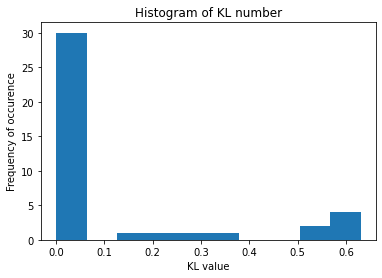

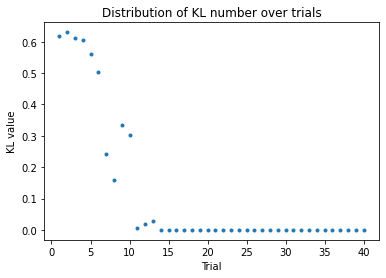

In [3]:
plt.figure()
plt.hist(my_data['KL_Number'])
plt.title("Histogram of KL number")
plt.xlabel("KL value")
plt.ylabel("Frequency of occurence")
plt.show()

plt.figure()
plt.plot(my_data.index,my_data['KL_Number'], '.')
plt.title("Distribution of KL number over trials")
plt.xlabel("Trial")
plt.ylabel("KL value")
plt.show()

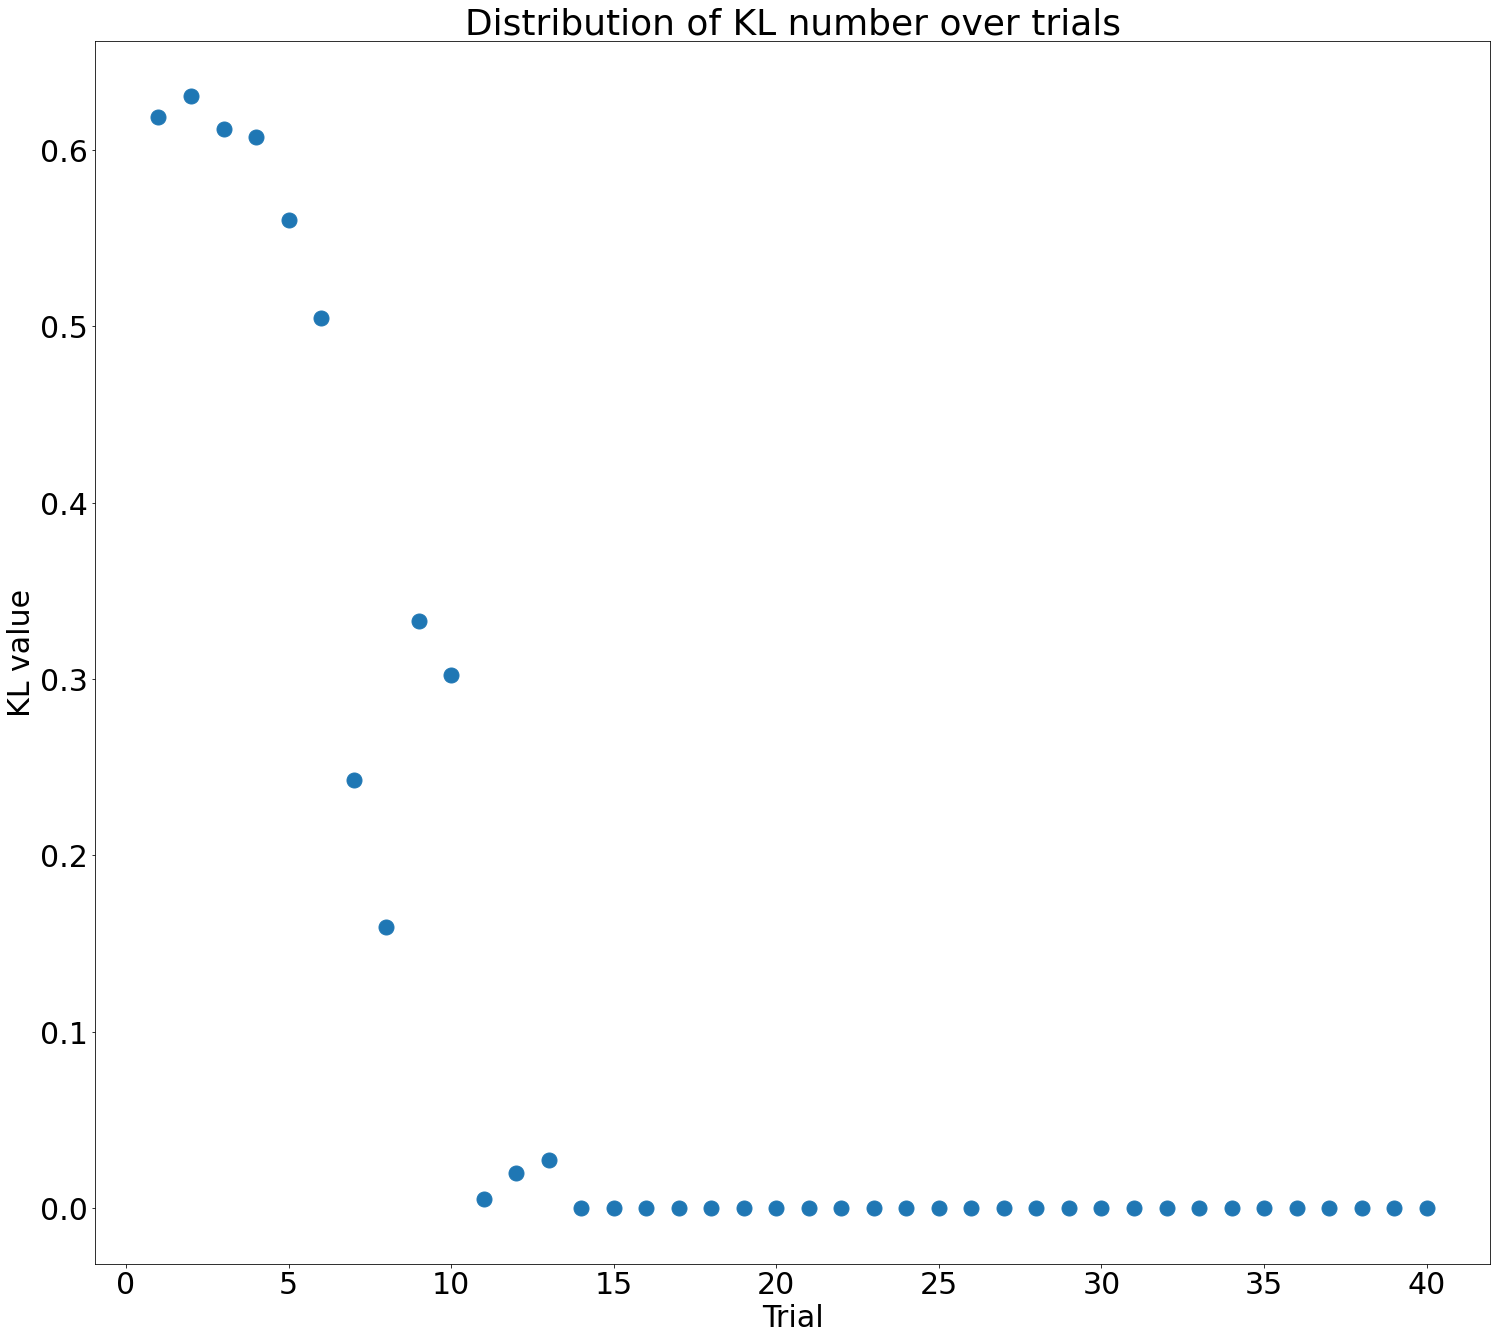

In [9]:
# Second plot with high resolution and custom size
# Set the font size
plt.rcParams.update({'font.size': 30})
plt.figure(figsize=(2000/80, 1800/80))  # Width and height in inches
plt.plot(my_data.index, my_data['KL_Number'], '.', markersize=30)
plt.title("Distribution of KL number over trials")
plt.xlabel("Trial")
plt.ylabel("KL value")
plt.savefig('high_resolution_plot.png', dpi=80)  # Save with a custom dpi
plt.show()

Supposedly you can see that the KL number stabilizes by the end of the experiment. When the KL number is close to zero it means that the question with the most estimated information gain was estimated to have almost zero information gain. Which means that all the other questions were estimated to have even less information gain. So asking those questions can't change the parameters much because the participant (you in this case) would most likely answer them with the same attitude she/he had when she/he answered the previous questions which determined the values of the parameters. 

Now we will look into the other parameters in order to see if they are reliably estimated. These parameters are:
- rho for risk aversion
- lambda for loss aversion
- mu for the consistency of the choice

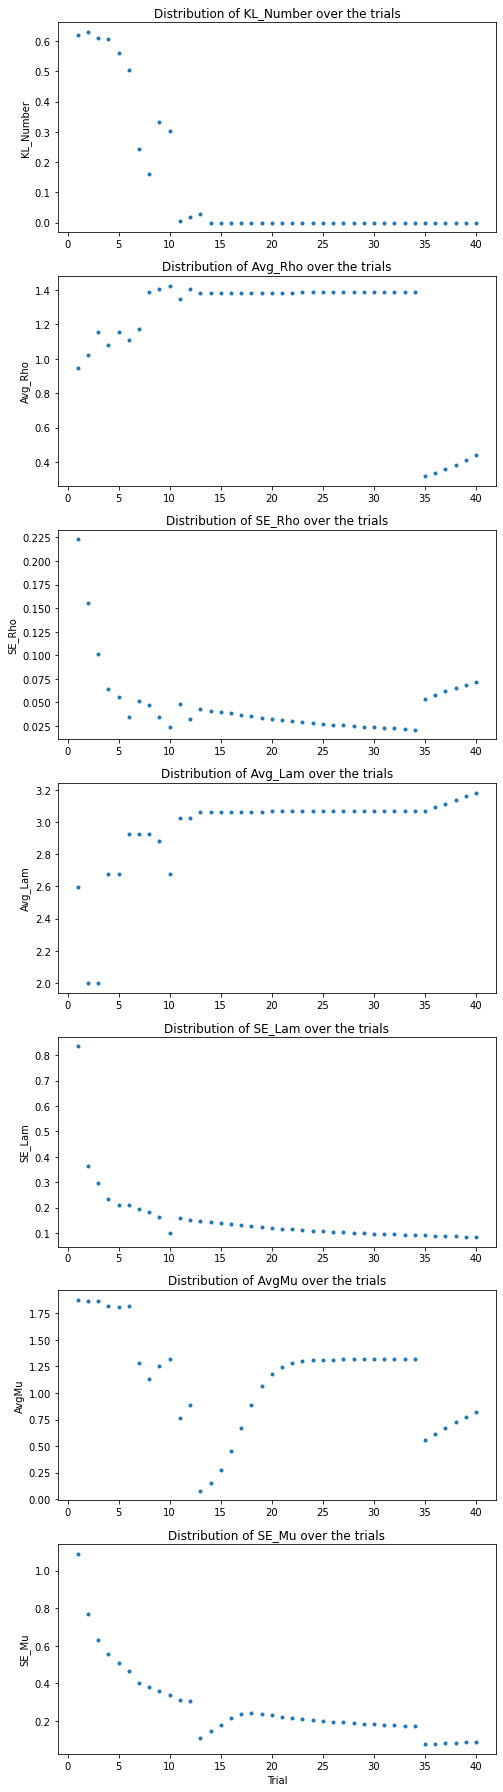

In [51]:
new_data = my_data.iloc[:,3:] #we only need to visualize some of the columns
del new_data['Answer'] #the same

fig, axes = plt.subplots(new_data.shape[1], 1, figsize=(7,25))
ax = axes.ravel()
for i in range(new_data.shape[1]):
    ax[i].plot(new_data.index,new_data.iloc[:,i], '.')
    ax[i].set_title("Distribution of "+new_data.columns[i]+" over the trials")
    ax[i].set_ylabel(new_data.columns[i])
ax[i].set_xlabel('Trial')
fig.tight_layout()

How could you describe the tendencies on the graphs? What conclusions could you make based on the distributions you see? Discuss with the group. Ask feedback from the instructor. 

In order to see why particular trends occured we could also explore the relationship between suggested win, loss and sure amounts and the answer of the participant.

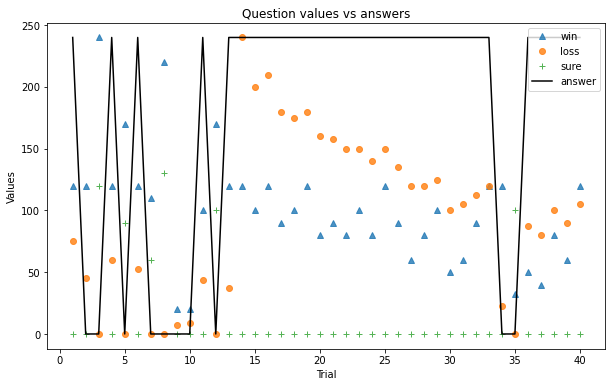

In [67]:
plt.figure(figsize = (10,6))
plt.plot(my_data.index, my_data['Win'],'^',label='win', alpha = .8)
plt.plot(my_data.index, my_data['Loss'],'o',label='loss', alpha = .8)
plt.plot(my_data.index, my_data['Sure'],'+',label='sure', alpha = .8)
plt.plot(my_data.index, (my_data['Answer']-1)*np.max(my_data['Win']),'k', label='answer')
plt.xlabel('Trial')
plt.ylabel('Values')
plt.title('Question values vs answers')
plt.legend(loc=1)
plt.show()

Describe the trends you see in the graph above (100-200 words) in the cell below. You can use the other graphs as a source of insights.  

### References
Wang, S. W., Filiba, M., & Camerer, C. F. (2010). Dynamically optimized sequential 
    experimentation (DOSE) for estimating economic preference parameters. Manuscript 
    submitted for publication.